# Uncertainty Signals — Exploratory Analysis

Goal: compute AUROCs for all signals across conditions, find the strongest stories in the data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Fountain Pen in a Lab Coat style
def setup_style():
    colors = {
        'off_white': '#FDFCFB',
        'charcoal': '#2C3E50',
        'teal': '#2D7F83',
        'muted_red': '#C0392B',
        'deep_blue': '#1E4D8A',
        'warm_gray_dark': '#8B95A1',
        'warm_gray_light': '#E8E6E3',
    }
    
    plt.style.use('default')
    plt.rcParams.update({
        'figure.figsize': (14, 8),
        'figure.dpi': 130,
        'figure.facecolor': colors['off_white'],
        'axes.facecolor': colors['off_white'],
        'axes.edgecolor': colors['warm_gray_dark'],
        'axes.labelcolor': colors['charcoal'],
        'text.color': colors['charcoal'],
        'xtick.color': colors['charcoal'],
        'ytick.color': colors['charcoal'],
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': True,
        'axes.spines.bottom': True,
        'axes.linewidth': 0.8,
        'grid.color': colors['warm_gray_light'],
        'grid.linestyle': ':',
        'grid.linewidth': 0.5,
        'grid.alpha': 0.3,
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 12,
        'legend.frameon': False,
        'legend.fancybox': False,
    })
    
    sns.set_palette("deep")
    return colors

COLORS = setup_style()

df = pd.read_csv('signals.csv')
print(f'Loaded {len(df):,} rows')
print(f'\nConditions:')
print(df.groupby(['condition', 'prompt_mode', 'shuffle', 'para']).agg(
    n=('question_id', 'count'),
    accuracy=('is_correct', 'mean')
).to_string())

Loaded 51,670 rows

Conditions:
                                                                      n  accuracy
condition                               prompt_mode shuffle para                 
exp1_full_cot_noshuffle_nopara          cot         False   False  5329  0.790955
exp1_full_cot_noshuffle_para            cot         False   True   5330  0.793621
exp1_full_cot_shuffle_nopara            cot         True    False  5330  0.809193
exp1_full_cot_shuffle_para              cot         True    True   5330  0.805066
exp1_full_direct_noshuffle_nopara       direct      False   False  5330  0.755347
exp1_full_direct_noshuffle_nopara_think direct      False   False  5204  0.883743
exp1_full_direct_noshuffle_para         direct      False   True   5330  0.758349
exp1_full_direct_shuffle_nopara         direct      True    False  5330  0.767355
exp1_full_direct_shuffle_para           direct      True    True   9157  0.776674


## 1. Accuracy Overview
First things first — how does each condition perform?

In [3]:
# Clean up: the direct_shuffle_para has a duplicate run (9157 rows). Keep only one.
# Also note the think condition has a slightly different name pattern
print('Row counts per condition before cleanup:')
print(df['condition'].value_counts().to_string())

# For direct_shuffle_para, if there are duplicates per question_id, keep the later run
dupes = df[df['condition'] == 'exp1_full_direct_shuffle_para'].groupby('question_id').size()
print(f'\nDuplicate question_ids in direct_shuffle_para: {(dupes > 1).sum()}')

# Deduplicate: keep last occurrence (later run)
df = df.drop_duplicates(subset=['condition', 'question_id'], keep='last')
print(f'\nAfter dedup: {len(df):,} rows')
print(df['condition'].value_counts().to_string())

Row counts per condition before cleanup:
condition
exp1_full_direct_shuffle_para              9157
exp1_full_direct_noshuffle_nopara          5330
exp1_full_cot_noshuffle_para               5330
exp1_full_cot_shuffle_para                 5330
exp1_full_cot_shuffle_nopara               5330
exp1_full_direct_shuffle_nopara            5330
exp1_full_direct_noshuffle_para            5330
exp1_full_cot_noshuffle_nopara             5329
exp1_full_direct_noshuffle_nopara_think    5204

Duplicate question_ids in direct_shuffle_para: 3827

After dedup: 47,843 rows
condition
exp1_full_cot_noshuffle_para               5330
exp1_full_direct_noshuffle_para            5330
exp1_full_cot_shuffle_nopara               5330
exp1_full_cot_shuffle_para                 5330
exp1_full_direct_noshuffle_nopara          5330
exp1_full_direct_shuffle_para              5330
exp1_full_direct_shuffle_nopara            5330
exp1_full_cot_noshuffle_nopara             5329
exp1_full_direct_noshuffle_nopara_think    5

In [4]:
# Accuracy by condition — the headline numbers
accuracy = df.groupby('condition').agg(
    n=('is_correct', 'count'),
    accuracy=('is_correct', 'mean'),
    prompt_mode=('prompt_mode', 'first'),
    shuffle=('shuffle', 'first'),
    para=('para', 'first')
).sort_values('accuracy', ascending=False)

accuracy['accuracy_pct'] = (accuracy['accuracy'] * 100).round(1)
print(accuracy[['prompt_mode', 'shuffle', 'para', 'n', 'accuracy_pct']].to_string())

                                        prompt_mode  shuffle   para     n  accuracy_pct
condition                                                                              
exp1_full_direct_noshuffle_nopara_think      direct    False  False  5204          88.4
exp1_full_cot_shuffle_nopara                    cot     True  False  5330          80.9
exp1_full_cot_shuffle_para                      cot     True   True  5330          80.5
exp1_full_cot_noshuffle_para                    cot    False   True  5330          79.4
exp1_full_cot_noshuffle_nopara                  cot    False  False  5329          79.1
exp1_full_direct_shuffle_para                direct     True   True  5330          77.3
exp1_full_direct_shuffle_nopara              direct     True  False  5330          76.7
exp1_full_direct_noshuffle_para              direct    False   True  5330          75.8
exp1_full_direct_noshuffle_nopara            direct    False  False  5330          75.5


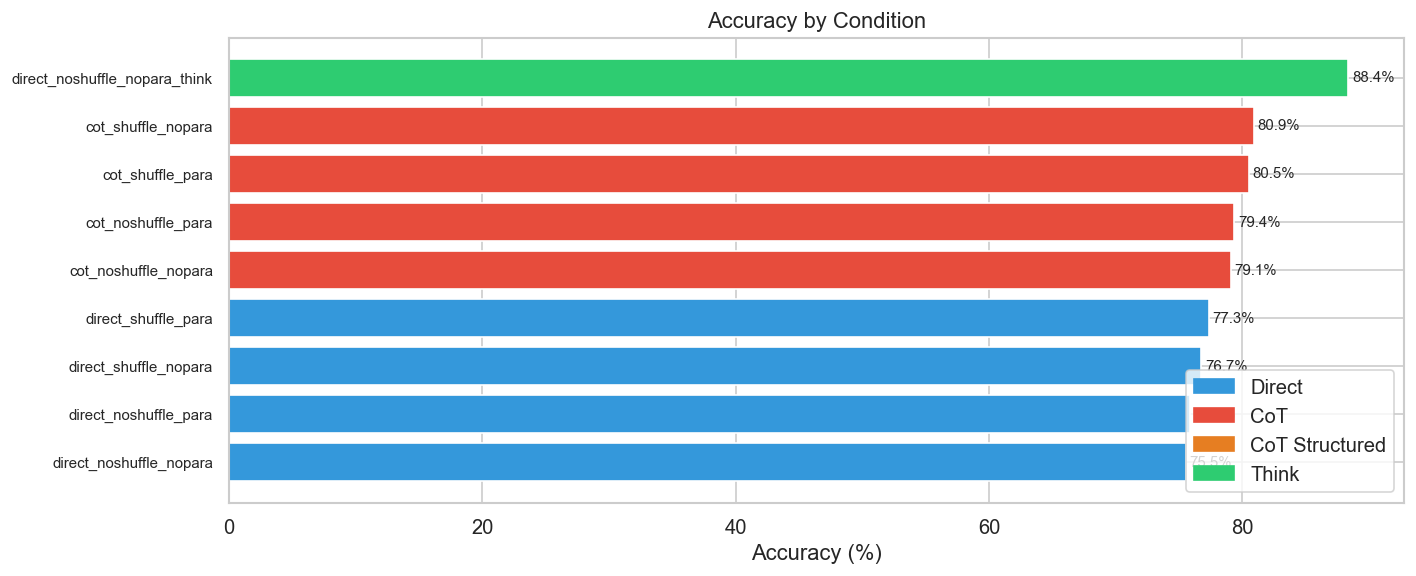

In [5]:
# Accuracy bar chart by prompt mode
fig, ax = plt.subplots(figsize=(14, 6))

acc_data = df.groupby('condition')['is_correct'].mean().sort_values(ascending=True)
colors_map = []
for cond in acc_data.index:
    if 'think' in cond: 
        colors_map.append(COLORS['deep_blue'])
    elif 'cot_' in cond and 'cotstruct' not in cond: 
        colors_map.append(COLORS['muted_red'])
    elif 'cotstruct' in cond: 
        colors_map.append(COLORS['warm_gray_dark'])
    else: 
        colors_map.append(COLORS['teal'])

bars = ax.barh(range(len(acc_data)), acc_data.values * 100, color=colors_map, edgecolor='none')
ax.set_yticks(range(len(acc_data)))
ax.set_yticklabels([c.replace('exp1_full_', '') for c in acc_data.index], fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=10)
ax.set_title('Accuracy by Condition', fontsize=12, fontweight=500)
ax.set_xlim(0, 105)

for bar, val in zip(bars, acc_data.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val*100:.1f}%', va='center', fontsize=8, color=COLORS['charcoal'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLORS['warm_gray_dark'])
ax.spines['bottom'].set_color(COLORS['warm_gray_dark'])
ax.tick_params(colors=COLORS['charcoal'], length=4)
fig.patch.set_facecolor(COLORS['off_white'])
ax.set_facecolor(COLORS['off_white'])

fig.tight_layout(pad=1.2)
plt.show()

## 2. AUROC Table — The Core Question

For each signal, how well does it separate correct from incorrect answers? Higher AUROC = better discriminator.

In [6]:
def compute_auroc(series, labels, higher_means_correct=True):
    """Compute AUROC, handling NaN and constant series."""
    mask = series.notna() & labels.notna()
    s, l = series[mask], labels[mask]
    if len(s) < 10 or l.nunique() < 2:
        return np.nan
    try:
        auc = roc_auc_score(l, s)
        if not higher_means_correct:
            auc = 1 - auc
        return auc
    except:
        return np.nan

# Define which signals exist and their direction
# higher_means_correct=True: higher value → more likely correct
# higher_means_correct=False: higher value → more likely INCORRECT (uncertainty signals)

single_query_signals = {
    'msp': True,                          # S1: max single-token prob
    'single_entropy': False,              # S2: entropy (high = uncertain)
    'second_gap': True,                   # S3: gap between top 2
    'answer_coverage': True,              # S5: off-label mass (NOVEL)
    'top_token_is_answer': True,          # S7: is top token an answer letter?
    'missing_letter_count': True,         # S7b: more missing = more certain
}

multi_query_signals = {
    'agreement': True,                    # S8: vote agreement
    'vote_entropy': False,                # S9: vote dispersion
    'mean_confidence': True,              # S10: mean of max probs
    'total_uncertainty': False,           # S11: entropy of mean dist
    'aleatoric': False,                   # S12: mean per-query entropy
    'epistemic': False,                   # S13: mutual information
    'confidence_variance': False,         # S14: stability of confidence (NOVEL)
    'second_gap_agg': True,              # S15: aggregated gap
    'rank_stability': True,              # S16: Kendall's tau
    'mean_pairwise_jsd': False,          # S15b: pairwise distributional divergence (NOVEL)
    'agreement_confidence_gap': True,     # S15c: agreement minus confidence (NOVEL)
    'effective_option_count': False,      # S17c: how many options in play
    'agg_answer_coverage': True,         # S17: mean answer coverage (NOVEL)
    'missing_letters_mean': True,        # S17b: mean missing letters
    'consistent_eliminations': True,     # S17b: robustly eliminated options
}

position_signals = {
    'position_loyalty': False,           # S19: high = position-driven (NOVEL)
    'position_preference_entropy': True, # S20: high = no position preference
}

all_signals = {**single_query_signals, **multi_query_signals, **position_signals}
print(f'Total signals to evaluate: {len(all_signals)}')

Total signals to evaluate: 23


In [7]:
# Compute AUROC for every signal × condition
conditions = sorted(df['condition'].unique())

auroc_results = []
for cond in conditions:
    cond_df = df[df['condition'] == cond]
    for signal, higher_correct in all_signals.items():
        auc = compute_auroc(cond_df[signal], cond_df['is_correct'], higher_correct)
        non_null = cond_df[signal].notna().sum()
        auroc_results.append({
            'condition': cond.replace('exp1_full_', ''),
            'signal': signal,
            'auroc': auc,
            'n_valid': non_null,
            'category': 'single' if signal in single_query_signals else 
                       'multi' if signal in multi_query_signals else 'position'
        })

auroc_df = pd.DataFrame(auroc_results)
print(f'Computed {len(auroc_df)} AUROCs ({auroc_df["auroc"].notna().sum()} valid)')

Computed 207 AUROCs (152 valid)


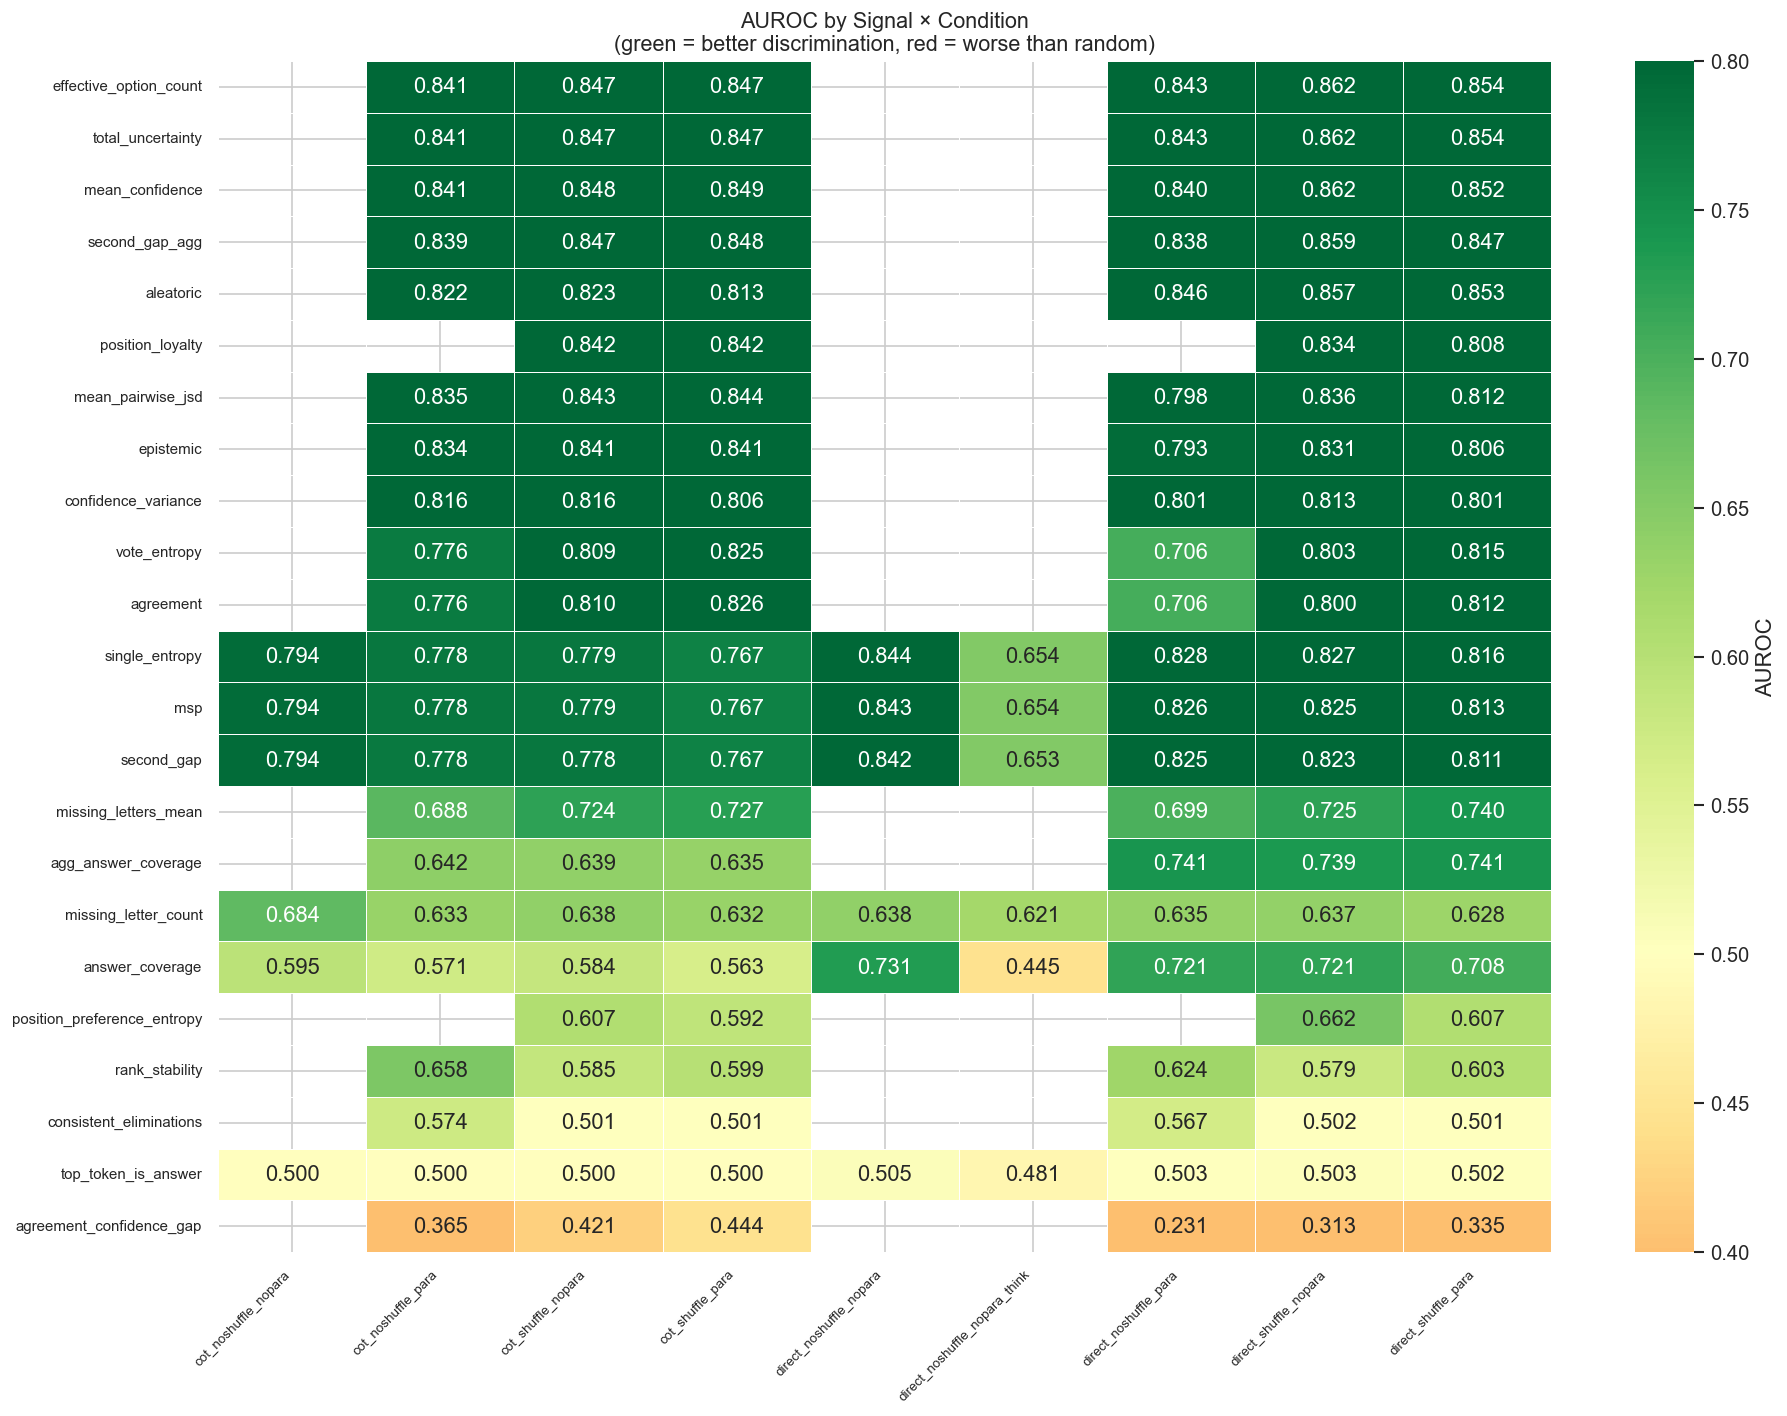

In [8]:
# AUROC heatmap — signals × conditions
pivot = auroc_df.pivot_table(index='signal', columns='condition', values='auroc')

# Order signals by mean AUROC (best at top)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

# Strip 'exp1_full_' from column names for readability
pivot.columns = [c.replace('exp1_full_', '') for c in pivot.columns]

fig, ax = plt.subplots(figsize=(16, 12))

# Create diverging colormap centered at 0.5
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=0.4, vcenter=0.5, vmax=0.8)

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            norm=norm, linewidths=0.3, ax=ax, linecolor=COLORS['warm_gray_light'],
            cbar_kws={'label': 'AUROC', 'shrink': 0.8},
            annot_kws={'fontsize': 8, 'color': COLORS['warm_gray_dark']})

ax.set_title('AUROC by Signal × Condition\n(green = better discrimination, red = worse than random)', 
             fontsize=12, fontweight=500, pad=20)
ax.set_ylabel('Signal', fontsize=10)
ax.set_xlabel('Condition', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)

for spine in ax.spines.values():
    spine.set_color(COLORS['warm_gray_dark'])
    spine.set_linewidth(0.8)

fig.patch.set_facecolor(COLORS['off_white'])
ax.set_facecolor(COLORS['off_white'])

fig.tight_layout(pad=1.2)
plt.show()

In [9]:
# Focus: Direct mode conditions (cleanest logprobs)
# Show the AUROC ranking for the key direct conditions
direct_conditions = [
    'direct_noshuffle_nopara',    # single query baseline
    'direct_noshuffle_para',      # paraphrases only
    'direct_shuffle_nopara',      # shuffling only
    'direct_shuffle_para',        # full diversification
]

direct_auroc = auroc_df[auroc_df['condition'].isin(direct_conditions)].copy()
direct_pivot = direct_auroc.pivot_table(index='signal', columns='condition', values='auroc')
direct_pivot = direct_pivot[direct_conditions]  # fix column order
direct_pivot = direct_pivot.loc[direct_pivot.mean(axis=1).sort_values(ascending=False).index]

print('=== AUROC TABLE: Direct Mode ===')
print('(higher = better at separating correct from incorrect)\n')
print(direct_pivot.round(3).to_string())
print(f'\n--- Best signal per condition ---')
for col in direct_pivot.columns:
    valid = direct_pivot[col].dropna()
    if len(valid) > 0:
        best = valid.idxmax()
        print(f'  {col}: {best} ({valid.max():.3f})')

=== AUROC TABLE: Direct Mode ===
(higher = better at separating correct from incorrect)

condition                    direct_noshuffle_nopara  direct_noshuffle_para  direct_shuffle_nopara  direct_shuffle_para
signal                                                                                                                 
effective_option_count                           NaN                  0.843                  0.862                0.854
total_uncertainty                                NaN                  0.843                  0.862                0.854
aleatoric                                        NaN                  0.846                  0.857                0.853
mean_confidence                                  NaN                  0.840                  0.862                0.852
second_gap_agg                                   NaN                  0.838                  0.859                0.847
single_entropy                                 0.844                  0

## 3. The Big Question: Does Combining Signals Help?

Logistic regression on confidence + consistency vs individual signals.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

def combined_auroc(features_df, labels, n_cv=5):
    """AUROC from logistic regression on multiple features, with cross-validation."""
    mask = features_df.notna().all(axis=1) & labels.notna()
    X, y = features_df[mask].values, labels[mask].values
    if len(X) < 50 or y.sum() < 10 or (1-y).sum() < 10:
        return np.nan, np.nan
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(clf, X_scaled, y, cv=n_cv, scoring='roc_auc')
    return scores.mean(), scores.std()

# For each multi-query direct condition, test combinations
for cond_name in ['direct_noshuffle_para', 'direct_shuffle_nopara', 'direct_shuffle_para']:
    full_cond = f'exp1_full_{cond_name}'
    cond_df = df[df['condition'] == full_cond].copy()
    if len(cond_df) == 0:
        continue
    
    print(f'\n=== {cond_name} (n={len(cond_df)}) ===')
    y = cond_df['is_correct'].astype(int)
    
    # Best single signal
    best_single_auc = 0
    best_single_name = ''
    for sig, higher in all_signals.items():
        auc = compute_auroc(cond_df[sig], y, higher)
        if auc is not np.nan and auc > best_single_auc:
            best_single_auc = auc
            best_single_name = sig
    print(f'Best single signal: {best_single_name} = {best_single_auc:.3f}')
    
    # 2D: confidence + consistency
    if cond_df['mean_confidence'].notna().sum() > 100 and cond_df['agreement'].notna().sum() > 100:
        auc_2d, std_2d = combined_auroc(cond_df[['mean_confidence', 'agreement']], y)
        print(f'2D (confidence + agreement): {auc_2d:.3f} ± {std_2d:.3f}')
    
    # 2D: confidence + epistemic
    if cond_df['mean_confidence'].notna().sum() > 100 and cond_df['epistemic'].notna().sum() > 100:
        auc_2d_epi, std_2d_epi = combined_auroc(cond_df[['mean_confidence', 'epistemic']], y)
        print(f'2D (confidence + epistemic): {auc_2d_epi:.3f} ± {std_2d_epi:.3f}')
    
    # All available signals combined
    avail = [s for s in all_signals if cond_df[s].notna().sum() > len(cond_df)*0.5]
    if len(avail) > 2:
        auc_all, std_all = combined_auroc(cond_df[avail], y)
        print(f'All signals combined ({len(avail)} features): {auc_all:.3f} ± {std_all:.3f}')


=== direct_noshuffle_para (n=5330) ===
Best single signal: aleatoric = 0.846
2D (confidence + agreement): 0.844 ± 0.018
2D (confidence + epistemic): 0.842 ± 0.016
All signals combined (21 features): 0.842 ± 0.015

=== direct_shuffle_nopara (n=5330) ===
Best single signal: mean_confidence = 0.862
2D (confidence + agreement): 0.864 ± 0.010
2D (confidence + epistemic): 0.862 ± 0.012
All signals combined (23 features): 0.861 ± 0.009

=== direct_shuffle_para (n=5330) ===
Best single signal: total_uncertainty = 0.854
2D (confidence + agreement): 0.854 ± 0.013
2D (confidence + epistemic): 0.852 ± 0.012
All signals combined (23 features): 0.855 ± 0.012


## 4. The 2D Uncertainty Space

Confidence × Consistency scatter, coloured by correctness. The headline figure.

In [11]:
# Use direct_shuffle_para as the showcase (full diversification)
showcase_cond = 'exp1_full_direct_shuffle_para'
sc = df[df['condition'] == showcase_cond].copy()
print(f'Showcase condition: {showcase_cond}')
print(f'Questions: {len(sc)}, Accuracy: {sc["is_correct"].mean():.1%}')
print(f'mean_confidence available: {sc["mean_confidence"].notna().sum()}')
print(f'agreement available: {sc["agreement"].notna().sum()}')

# Check what consistency signals are available
for sig in ['agreement', 'epistemic', 'rank_stability', 'confidence_variance', 'mean_pairwise_jsd']:
    n_valid = sc[sig].notna().sum()
    print(f'  {sig}: {n_valid} non-null')

Showcase condition: exp1_full_direct_shuffle_para
Questions: 5330, Accuracy: 77.3%
mean_confidence available: 5330
agreement available: 5330
  agreement: 5330 non-null
  epistemic: 5330 non-null
  rank_stability: 5330 non-null
  confidence_variance: 5330 non-null
  mean_pairwise_jsd: 5330 non-null


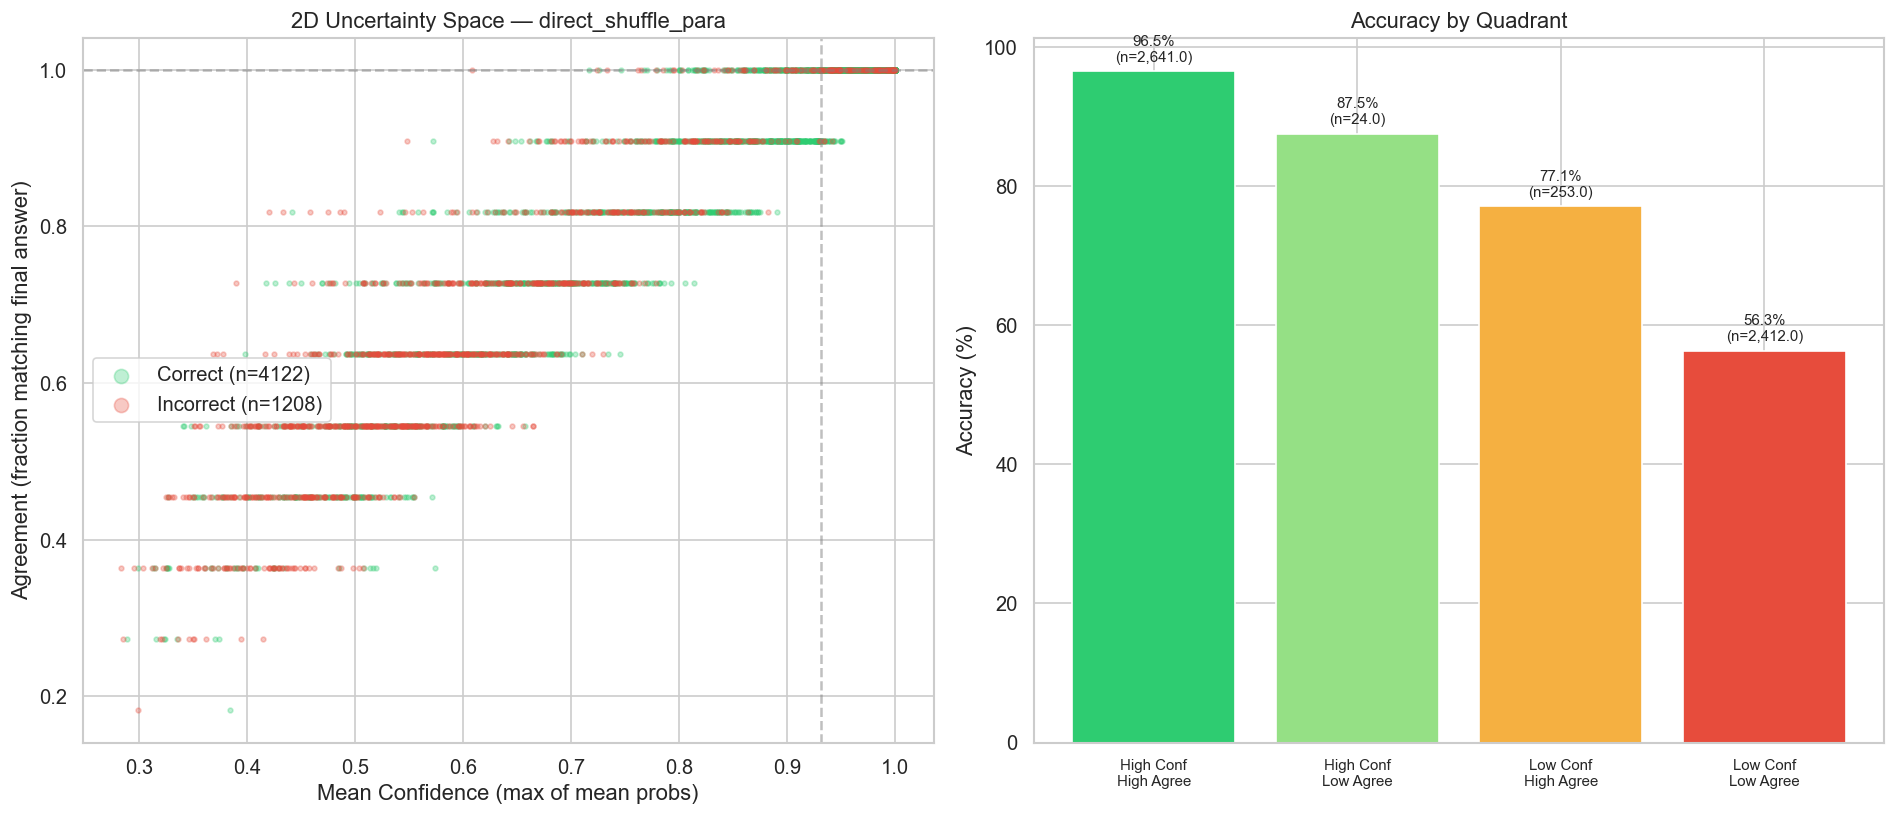


Quadrant breakdown:
                          n  accuracy
quadrant                             
High Conf\nHigh Agree  2641  0.964786
High Conf\nLow Agree     24  0.875000
Low Conf\nHigh Agree    253  0.770751
Low Conf\nLow Agree    2412  0.563018


In [12]:
# 2D Scatter: Confidence × Agreement
plot_df = sc.dropna(subset=['mean_confidence', 'agreement']).copy()

if len(plot_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Left: coloured by correctness
    ax = axes[0]
    correct = plot_df[plot_df['is_correct'] == True]
    incorrect = plot_df[plot_df['is_correct'] == False]
    ax.scatter(correct['mean_confidence'], correct['agreement'], 
               alpha=0.25, s=20, c=COLORS['teal'], label=f'Correct (n={len(correct)})', edgecolors='none')
    ax.scatter(incorrect['mean_confidence'], incorrect['agreement'], 
               alpha=0.25, s=20, c=COLORS['muted_red'], label=f'Incorrect (n={len(incorrect)})', edgecolors='none')
    
    # Quadrant lines in warm gray dashed
    ax.axvline(plot_df['mean_confidence'].median(), color=COLORS['warm_gray_dark'], 
               linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(plot_df['agreement'].median(), color=COLORS['warm_gray_dark'], 
               linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_xlabel('Mean Confidence (max of mean probs)', fontsize=10)
    ax.set_ylabel('Agreement (fraction matching final answer)', fontsize=10)
    ax.set_title('2D Uncertainty Space: Confidence × Agreement', fontsize=12, fontweight=500)
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLORS['warm_gray_dark'])
    ax.spines['bottom'].set_color(COLORS['warm_gray_dark'])
    ax.tick_params(colors=COLORS['charcoal'], length=4)
    ax.set_facecolor(COLORS['off_white'])
    ax.grid(True, color=COLORS['warm_gray_light'], linestyle=':', alpha=0.3)
    
    # Right: coloured by accuracy in quadrants
    ax = axes[1]
    
    conf_median = plot_df['mean_confidence'].median()
    agree_median = plot_df['agreement'].median()
    
    quadrants = [
        {'label': 'High C\nHigh A', 'conf': (conf_median, plot_df['mean_confidence'].max()), 
         'agree': (agree_median, plot_df['agreement'].max())},
        {'label': 'Low C\nHigh A', 'conf': (plot_df['mean_confidence'].min(), conf_median), 
         'agree': (agree_median, plot_df['agreement'].max())},
        {'label': 'Low C\nLow A', 'conf': (plot_df['mean_confidence'].min(), conf_median), 
         'agree': (plot_df['agreement'].min(), agree_median)},
        {'label': 'High C\nLow A', 'conf': (conf_median, plot_df['mean_confidence'].max()), 
         'agree': (plot_df['agreement'].min(), agree_median)},
    ]
    
    quad_accs = []
    for quad in quadrants:
        mask = ((plot_df['mean_confidence'] >= quad['conf'][0]) & 
                (plot_df['mean_confidence'] <= quad['conf'][1]) & 
                (plot_df['agreement'] >= quad['agree'][0]) & 
                (plot_df['agreement'] <= quad['agree'][1]))
        acc = plot_df.loc[mask, 'is_correct'].mean() if mask.sum() > 0 else 0
        quad_accs.append(acc)
    
    # Teal gradient: darkest (best) to lightest (worst)
    teal_palette = ['#0F4C47', '#1B6B68', '#2D7F83', '#5FA3A6']
    sorted_indices = sorted(range(len(quad_accs)), key=lambda i: quad_accs[i], reverse=True)
    
    bars = ax.bar(range(len(quadrants)), [quad_accs[i] * 100 for i in sorted_indices], 
                  color=[teal_palette[i] for i in range(len(quadrants))], edgecolor='none')
    ax.set_xticks(range(len(quadrants)))
    ax.set_xticklabels([quadrants[i]['label'] for i in sorted_indices], fontsize=9)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_title('Accuracy by Confidence-Agreement Quadrant', fontsize=12, fontweight=500)
    ax.set_ylim(0, 105)
    
    for bar, val_idx in zip(bars, sorted_indices):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{quad_accs[val_idx]*100:.0f}%', ha='center', fontsize=9, color=COLORS['charcoal'])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLORS['warm_gray_dark'])
    ax.spines['bottom'].set_color(COLORS['warm_gray_dark'])
    ax.tick_params(colors=COLORS['charcoal'], length=4)
    ax.set_facecolor(COLORS['off_white'])
    ax.grid(True, axis='y', color=COLORS['warm_gray_light'], linestyle=':', alpha=0.3)
    
    fig.patch.set_facecolor(COLORS['off_white'])
    fig.tight_layout(pad=1.2)
    plt.show()

## 5. Novel Signal Spotlight

Do the novel signals (answer coverage, position loyalty, agreement-confidence gap) actually add anything?

In [13]:
# Answer coverage: correct vs incorrect distributions
for cond_name in ['direct_noshuffle_nopara', 'direct_shuffle_para']:
    full_cond = f'exp1_full_{cond_name}'
    cond_df = df[df['condition'] == full_cond]
    
    # Check which coverage signal has data
    for sig in ['answer_coverage', 'agg_answer_coverage']:
        valid = cond_df[sig].notna().sum()
        if valid > 100:
            correct_vals = cond_df.loc[cond_df['is_correct'] == True, sig]
            incorrect_vals = cond_df.loc[cond_df['is_correct'] == False, sig]
            print(f'{cond_name} / {sig}:')
            print(f'  Correct:   mean={correct_vals.mean():.3f}, median={correct_vals.median():.3f}')
            print(f'  Incorrect: mean={incorrect_vals.mean():.3f}, median={incorrect_vals.median():.3f}')
            auc = compute_auroc(cond_df[sig], cond_df['is_correct'], True)
            print(f'  AUROC: {auc:.3f}\n')

direct_noshuffle_nopara / answer_coverage:
  Correct:   mean=0.964, median=0.982
  Incorrect: mean=0.921, median=0.949
  AUROC: 0.731

direct_shuffle_para / answer_coverage:
  Correct:   mean=0.962, median=0.980
  Incorrect: mean=0.923, median=0.949
  AUROC: 0.708

direct_shuffle_para / agg_answer_coverage:
  Correct:   mean=0.961, median=0.975
  Incorrect: mean=0.921, median=0.941
  AUROC: 0.741



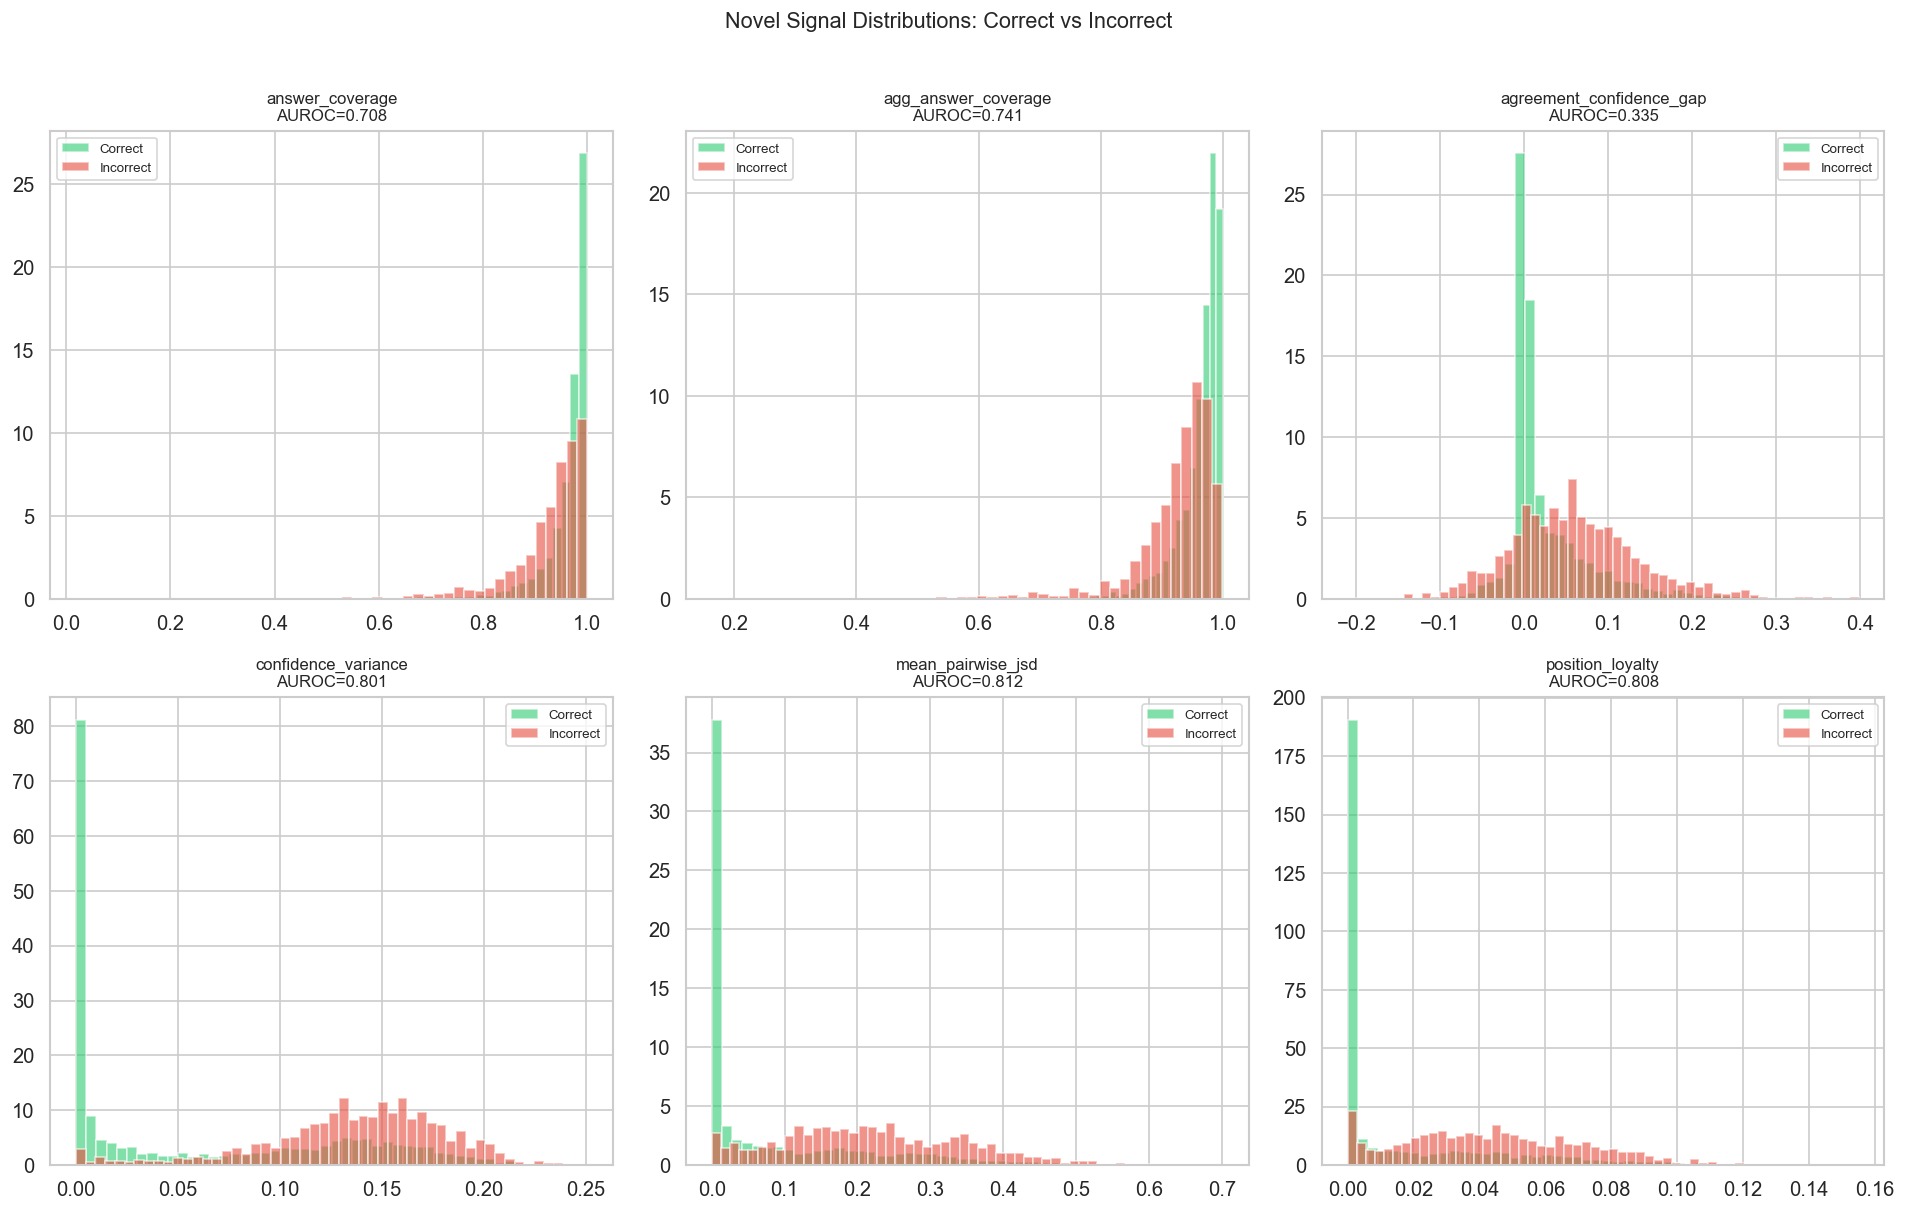

In [14]:
# Novel signal distributions: correct vs incorrect
novel_signals = ['answer_coverage', 'agg_answer_coverage', 'agreement_confidence_gap', 
                 'confidence_variance', 'mean_pairwise_jsd', 'position_loyalty']

cond_df = df[df['condition'] == 'exp1_full_direct_shuffle_para'].copy()

available_novels = [s for s in novel_signals if cond_df[s].notna().sum() > 100]
if available_novels:
    n_plots = len(available_novels)
    fig, axes = plt.subplots(2, (n_plots+1)//2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, sig in enumerate(available_novels):
        ax = axes[i]
        correct = cond_df.loc[cond_df['is_correct'] == True, sig].dropna()
        incorrect = cond_df.loc[cond_df['is_correct'] == False, sig].dropna()
        
        ax.hist(correct, bins=40, alpha=0.5, color=COLORS['teal'], 
                label=f'Correct (n={len(correct)})', edgecolor='none')
        ax.hist(incorrect, bins=40, alpha=0.5, color=COLORS['muted_red'], 
                label=f'Incorrect (n={len(incorrect)})', edgecolor='none')
        
        ax.set_xlabel(sig.replace('_', ' ').title(), fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.set_title(sig.replace('_', ' ').title(), fontsize=11, fontweight=500)
        ax.legend(loc='upper right', frameon=False, fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color(COLORS['warm_gray_dark'])
        ax.spines['bottom'].set_color(COLORS['warm_gray_dark'])
        ax.tick_params(colors=COLORS['charcoal'], labelsize=8, length=4)
        ax.set_facecolor(COLORS['off_white'])
        ax.grid(True, axis='y', color=COLORS['warm_gray_light'], linestyle=':', alpha=0.3)
    
    # Hide extra subplots
    for j in range(len(available_novels), len(axes)):
        axes[j].set_visible(False)
    
    fig.patch.set_facecolor(COLORS['off_white'])
    fig.tight_layout(pad=1.2)
    plt.show()

## 6. Scaffolding Absorption — Direct vs CoT vs Think

How does reasoning mode affect logprob spread?

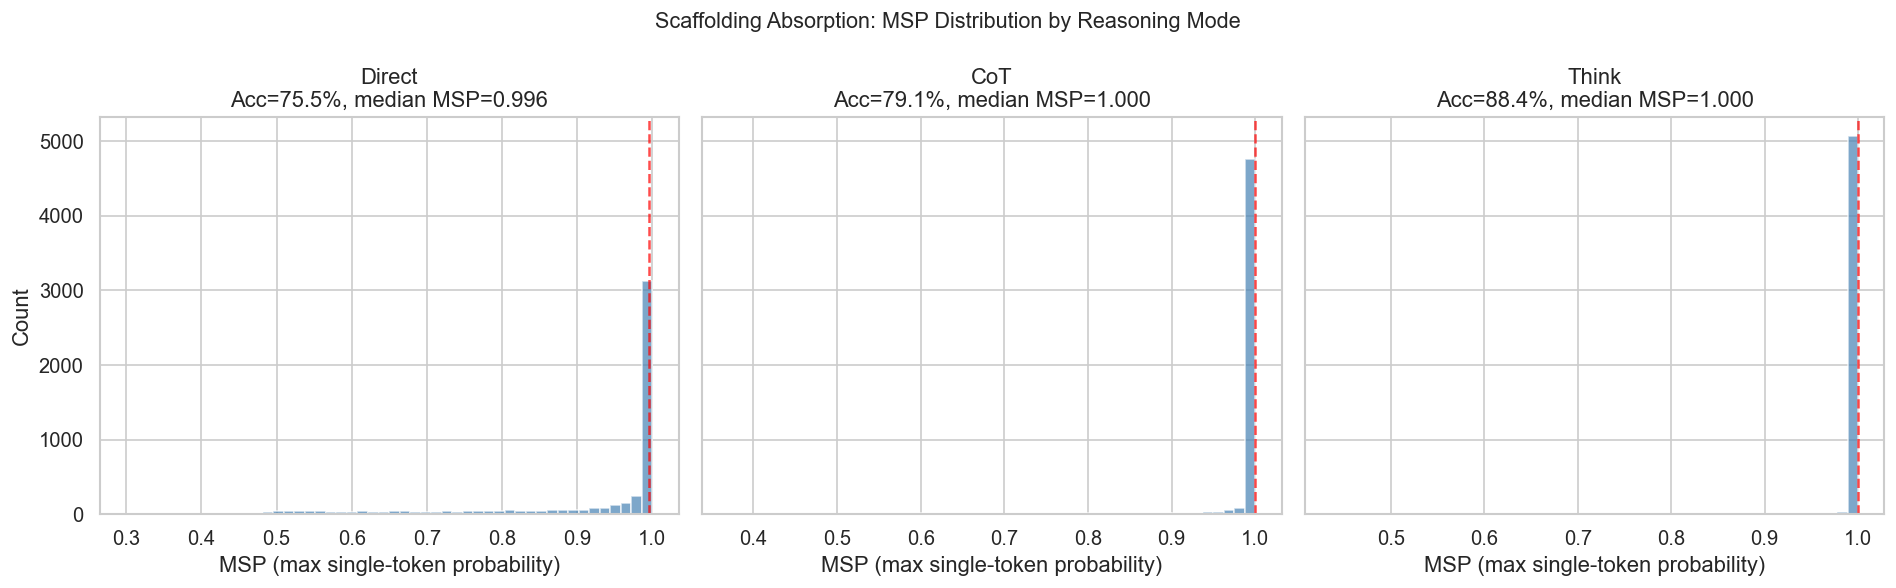


MSP Summary by Mode:
  Direct  : n= 5330, acc=75.5%, MSP mean=0.907, median=0.996, >0.99=56.2%
  CoT     : n= 5329, acc=79.1%, MSP mean=0.981, median=1.000, >0.99=88.6%
  Think   : n= 5204, acc=88.4%, MSP mean=0.996, median=1.000, >0.99=97.3%


In [15]:
# Compare logprob spread across prompt modes (noshuffle_nopara — single query, cleanest comparison)
baseline_conds = [
    ('Direct', 'exp1_full_direct_noshuffle_nopara'),
    ('CoT', 'exp1_full_cot_noshuffle_nopara'),
    ('Think', 'exp1_full_direct_noshuffle_nopara_think'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Teal-to-blue gradient for the 3 modes
mode_colors = [COLORS['teal'], '#4A9D9F', COLORS['deep_blue']]

for idx, (label, cond) in enumerate(baseline_conds):
    ax = axes[idx]
    cond_df = df[df['condition'] == cond]
    if len(cond_df) == 0:
        ax.set_title(f'{label}\n(no data)', fontsize=11, fontweight=500)
        continue
    
    msp_vals = cond_df['msp'].dropna()
    acc = cond_df['is_correct'].mean()
    ax.hist(msp_vals, bins=50, color=mode_colors[idx], alpha=0.7, edgecolor='none')
    ax.set_xlabel('MSP (max single-token probability)', fontsize=9)
    ax.set_ylabel('Count' if idx == 0 else '', fontsize=9)
    ax.set_title(f'{label}\nAcc={acc:.1%}', fontsize=11, fontweight=500)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COLORS['warm_gray_dark'])
    ax.spines['bottom'].set_color(COLORS['warm_gray_dark'])
    ax.tick_params(colors=COLORS['charcoal'], labelsize=9, length=4)
    ax.set_facecolor(COLORS['off_white'])
    ax.grid(True, axis='y', color=COLORS['warm_gray_light'], linestyle=':', alpha=0.3)

fig.patch.set_facecolor(COLORS['off_white'])
fig.tight_layout(pad=1.2)
plt.show()

In [16]:
# AUROC comparison across modes for single-query signals
print('=== Single-query signal AUROCs by reasoning mode ===')
print('(noshuffle_nopara conditions — one query per question)\n')

mode_results = []
for label, cond in baseline_conds:
    cond_df = df[df['condition'] == cond]
    if len(cond_df) == 0: continue
    for sig, higher in single_query_signals.items():
        auc = compute_auroc(cond_df[sig], cond_df['is_correct'], higher)
        mode_results.append({'mode': label, 'signal': sig, 'auroc': auc})

mode_df = pd.DataFrame(mode_results)
mode_pivot = mode_df.pivot_table(index='signal', columns='mode', values='auroc')
if 'Direct' in mode_pivot.columns:
    mode_pivot = mode_pivot[['Direct', 'CoT', 'Think']]
print(mode_pivot.round(3).to_string())

=== Single-query signal AUROCs by reasoning mode ===
(noshuffle_nopara conditions — one query per question)

mode                  Direct    CoT  Think
signal                                    
answer_coverage        0.731  0.595  0.445
missing_letter_count   0.638  0.684  0.621
msp                    0.843  0.794  0.654
second_gap             0.842  0.794  0.653
single_entropy         0.844  0.794  0.654
top_token_is_answer    0.505  0.500  0.481


## 7. Signal Correlations

How many independent dimensions of uncertainty are there really?

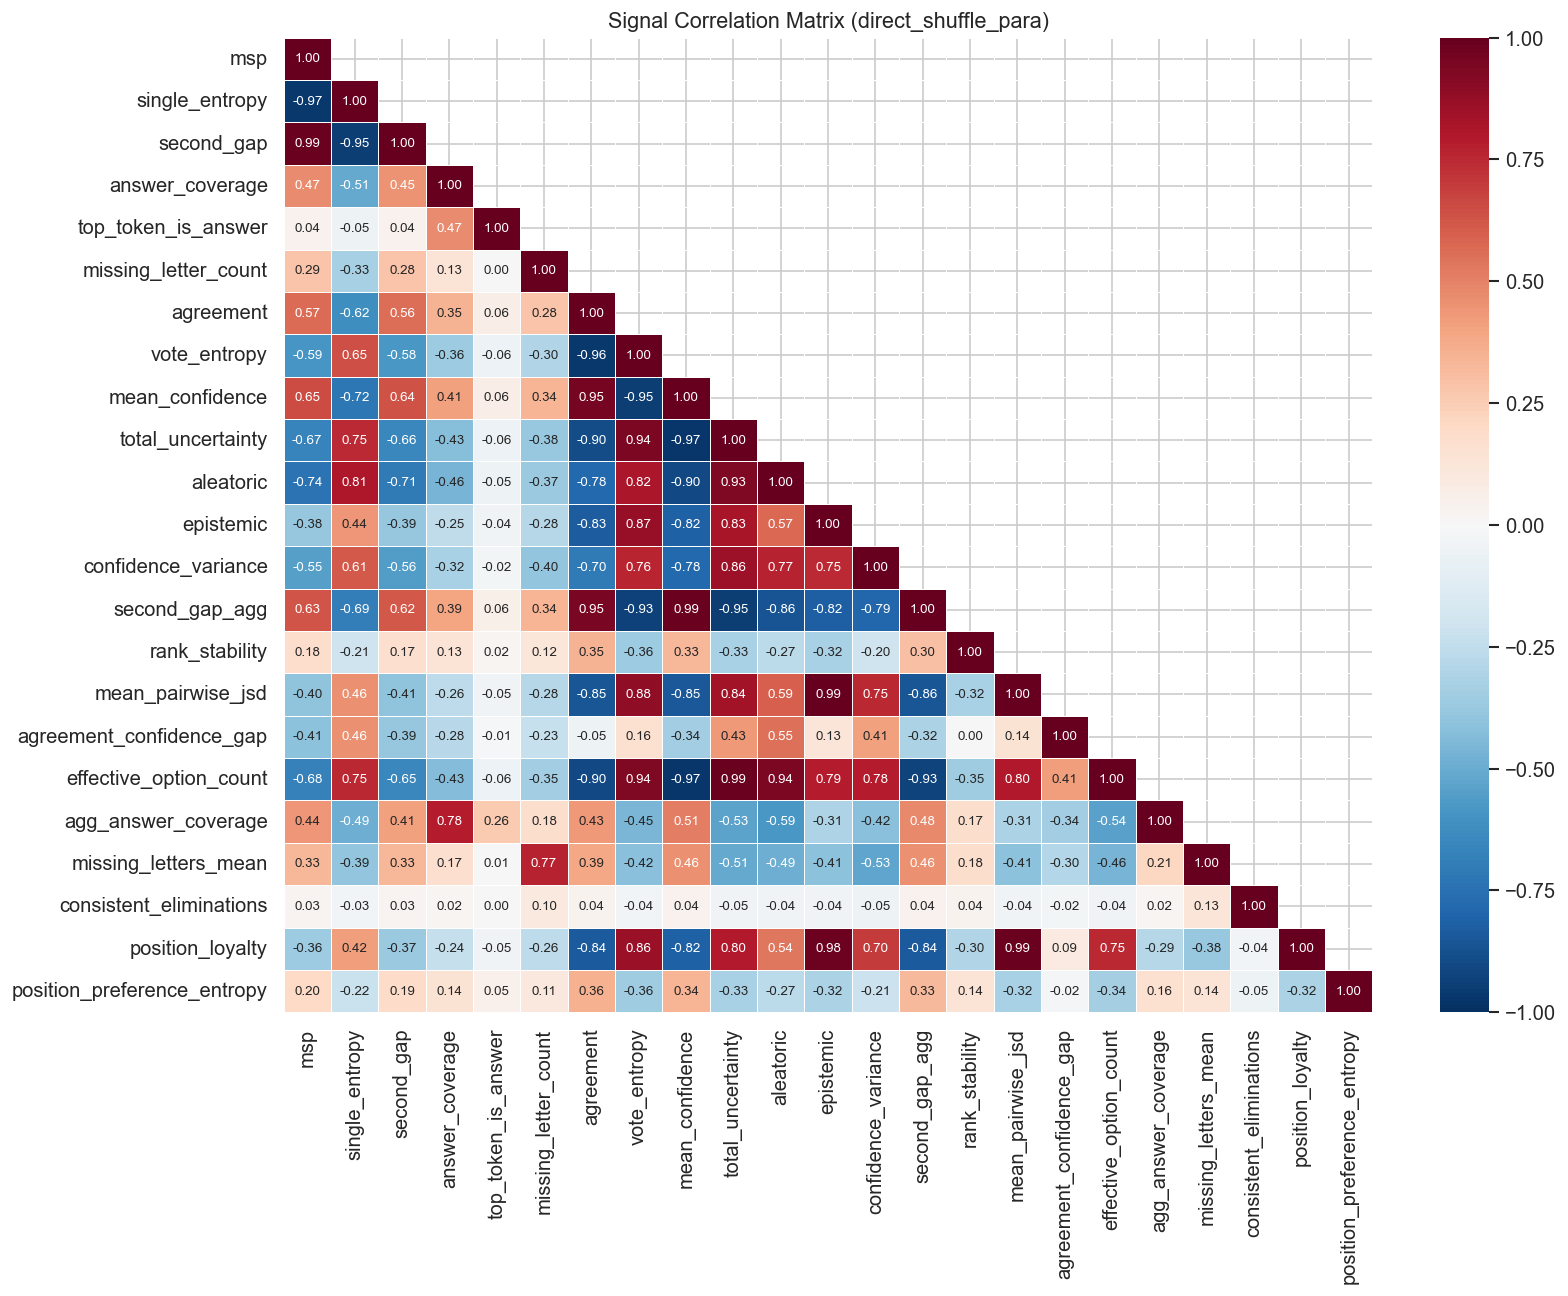


PCA of signal correlation matrix:
  PC1: eigenvalue=12.23, explained=53.2%, cumulative=53.2%
  PC2: eigenvalue=2.38, explained=10.3%, cumulative=63.5%
  PC3: eigenvalue=1.63, explained=7.1%, cumulative=70.6%
  PC4: eigenvalue=1.32, explained=5.8%, cumulative=76.3%
  PC5: eigenvalue=0.99, explained=4.3%, cumulative=80.6%
  PC6: eigenvalue=0.95, explained=4.1%, cumulative=84.8%
  PC7: eigenvalue=0.85, explained=3.7%, cumulative=88.5%
  PC8: eigenvalue=0.79, explained=3.4%, cumulative=91.9%
  PC9: eigenvalue=0.61, explained=2.7%, cumulative=94.5%

  → 10 components explain 95% of variance


In [17]:
# Correlation matrix for the direct_shuffle_para condition
cond_df = df[df['condition'] == 'exp1_full_direct_shuffle_para'].copy()

# Select signals with enough data
corr_signals = [s for s in all_signals if cond_df[s].notna().sum() > len(cond_df) * 0.3]

if len(corr_signals) > 3:
    corr_matrix = cond_df[corr_signals].corr()
    
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    # Create a custom teal-blue diverging colormap
    from matplotlib.colors import LinearSegmentedColormap
    colors_list = [COLORS['muted_red'], COLORS['off_white'], COLORS['teal']]
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('teal_diverge', colors_list, N=n_bins)
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap=cmap, 
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
                linecolor=COLORS['warm_gray_light'],
                cbar_kws={'label': 'Correlation', 'shrink': 0.8},
                annot_kws={'fontsize': 8, 'color': COLORS['warm_gray_dark']})
    
    ax.set_title('Signal Correlation Matrix (direct_shuffle_para)', fontsize=12, fontweight=500, pad=20)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    
    for spine in ax.spines.values():
        spine.set_color(COLORS['warm_gray_dark'])
        spine.set_linewidth(0.8)
    
    fig.patch.set_facecolor(COLORS['off_white'])
    ax.set_facecolor(COLORS['off_white'])
    
    fig.tight_layout(pad=1.2)
    plt.show()
    
    # How many independent dimensions?
    eigenvalues = np.linalg.eigvals(corr_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    pct_var = eigenvalues / eigenvalues.sum() * 100
    cumsum_var = np.cumsum(pct_var)
    n_dims = (cumsum_var < 90).sum() + 1
    print(f'\nTo capture 90% of variance: {n_dims} dimensions')
    print(f'Top 3 eigenvalues: {eigenvalues[:3]}')

## 8. Quick Summary — What Stories Are In The Data?

In [18]:
# Print a summary of the most important findings
print('='*70)
print('SUMMARY: Key Numbers for Paper Direction')
print('='*70)

# 1. Accuracy by mode
print('\n1. ACCURACY BY MODE')
for label, cond in baseline_conds:
    cond_df = df[df['condition'] == cond]
    if len(cond_df) > 0:
        print(f'   {label:8s}: {cond_df["is_correct"].mean():.1%} ({len(cond_df)} questions)')

# 2. Best single signal
print('\n2. BEST SINGLE SIGNALS (direct_shuffle_para)')
cond_df = df[df['condition'] == 'exp1_full_direct_shuffle_para']
signal_aucs = []
for sig, higher in all_signals.items():
    auc = compute_auroc(cond_df[sig], cond_df['is_correct'], higher)
    if pd.notna(auc):
        signal_aucs.append((sig, auc))
signal_aucs.sort(key=lambda x: x[1], reverse=True)
for sig, auc in signal_aucs[:10]:
    novel = ' ★' if sig in ['answer_coverage', 'agg_answer_coverage', 'confidence_variance', 
                             'mean_pairwise_jsd', 'agreement_confidence_gap', 
                             'position_loyalty'] else ''
    print(f'   {auc:.3f}  {sig}{novel}')

# 3. Does paraphrasing help?
print('\n3. DOES PARAPHRASING HELP? (direct mode, best signal AUROC)')
for cond_name in ['direct_noshuffle_nopara', 'direct_noshuffle_para', 
                   'direct_shuffle_nopara', 'direct_shuffle_para']:
    full_cond = f'exp1_full_{cond_name}'
    cond_df = df[df['condition'] == full_cond]
    best_auc = 0
    best_sig = ''
    for sig, higher in all_signals.items():
        auc = compute_auroc(cond_df[sig], cond_df['is_correct'], higher)
        if pd.notna(auc) and auc > best_auc:
            best_auc = auc
            best_sig = sig
    print(f'   {cond_name:30s}: best AUROC = {best_auc:.3f} ({best_sig})')

# 4. Distribution shapes
print('\n4. DISTRIBUTION SHAPES (direct_noshuffle_nopara)')
baseline = df[df['condition'] == 'exp1_full_direct_noshuffle_nopara']
if 'distribution_shape' in baseline.columns:
    shape_acc = baseline.groupby('distribution_shape')['is_correct'].agg(['count', 'mean'])
    shape_acc.columns = ['n', 'accuracy']
    print(shape_acc.sort_values('accuracy', ascending=False).to_string())

print('\n' + '='*70)

SUMMARY: Key Numbers for Paper Direction

1. ACCURACY BY MODE
   Direct  : 75.5% (5330 questions)
   CoT     : 79.1% (5329 questions)
   Think   : 88.4% (5204 questions)

2. BEST SINGLE SIGNALS (direct_shuffle_para)
   0.854  total_uncertainty
   0.854  effective_option_count
   0.853  aleatoric
   0.852  mean_confidence
   0.847  second_gap_agg
   0.816  single_entropy
   0.815  vote_entropy
   0.813  msp
   0.812  mean_pairwise_jsd ★
   0.812  agreement

3. DOES PARAPHRASING HELP? (direct mode, best signal AUROC)
   direct_noshuffle_nopara       : best AUROC = 0.844 (single_entropy)
   direct_noshuffle_para         : best AUROC = 0.846 (aleatoric)
   direct_shuffle_nopara         : best AUROC = 0.862 (mean_confidence)
   direct_shuffle_para           : best AUROC = 0.854 (total_uncertainty)

4. DISTRIBUTION SHAPES (direct_noshuffle_nopara)
                       n  accuracy
distribution_shape                
peaked              4294  0.836749
flat                  10  0.500000
bimoda